In [3]:
# Para el manejo de datos
import pandas as pd

# Para el análisis propiamente
import re
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# I. DELIMITANDO VARIABLES

In [2]:
# 1. Cargamos el archivo
df = pd.read_csv("convocatorias_sociales_pe.csv", encoding="utf-8")

In [3]:
# 2. Mostramos las primeras filas para comprobar que las tildes y eñes se ven perfectas
display(df.head(10))

,id,site,job_url,job_url_direct,title,company,location,date_posted,job_type,salary_source,...,company_num_employees,company_revenue,company_description,skills,experience_range,company_rating,company_reviews_count,vacancy_count,work_from_home_type,termino_de_busqueda
0,in-f7f5f1d41f45f156,indeed,https://pe.indeed.com/viewjob?jk=f7f5f1d41f45f156,https://worldvision.wd1.myworkdayjobs.com/es/W...,Facilitador/a de Desarrollo,World Vision International,"El Salvador, CAJ, PE",2026-07-31,fulltime,NaN,...,"10,000+",$1B to $5B (USD),We help the most vulnerable girls and boys ove...,NaN,NaN,NaN,NaN,NaN,NaN,"""Sociologia"""
1,in-398ae61bcb5d821e,indeed,https://pe.indeed.com/viewjob?jk=398ae61bcb5d821e,https://venparanexa.gupy.io/job/eyJqb2JJZCI6MT...,Jefe de Gestión Social - Temporal | El Porvenir,Nexa Resources,"Yanacancha, PAS, PE",2026-07-31,temporary,NaN,...,"1,001 to 5,000",Decline to state,Levamos a essência do mundo da mineração para ...,NaN,NaN,NaN,NaN,NaN,NaN,"""Sociologia"""
2,in-0b486694b423ce9b,indeed,https://pe.indeed.com/viewjob?jk=0b486694b423ce9b,http://pe.indeed.com/job/jefe-de-recursos-huma...,Jefe(a) de Recursos Humanos,ARGOS SOLUCIONES B Y C SAC,"Independencia, LIM, PE",2026-07-30,fulltime,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""Sociologia"""
3,in-26e0adcc54f7eecf,indeed,https://pe.indeed.com/viewjob?jk=26e0adcc54f7eecf,https://jobs.engie.com/default/job/Jefe-de-Ges...,Jefe de Gestion Territorial - Lima,ENGIE,"Chorrillos, LIM, PE",2026-07-30,NaN,NaN,...,"10,000+",more than $10B (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""Sociologia"""
4,in-6f9b4a70148f6a96,indeed,https://pe.indeed.com/viewjob?jk=6f9b4a70148f6a96,http://pe.indeed.com/job/soci%C3%B3logo-6f9b4a...,Sociólogo,CDH Empresarial,"Piura, PIU, PE",2026-07-28,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""Sociologia"""
5,in-c06ca0fc0b2a3d7c,indeed,https://pe.indeed.com/viewjob?jk=c06ca0fc0b2a3d7c,https://acciona.wd3.myworkdayjobs.com/en-US/AC...,ANALISTA PREDIAL,Acciona,"Lima, LIM, PE",2026-07-27,NaN,NaN,...,"10,000+",more than $10B (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""Sociologia"""
6,in-5040e485810dd595,indeed,https://pe.indeed.com/viewjob?jk=5040e485810dd595,https://acciona.wd3.myworkdayjobs.com/en-US/AC...,ASISTENTE PREDIAL,Acciona,"Lima, LIM, PE",2026-07-27,NaN,NaN,...,"10,000+",more than $10B (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""Sociologia"""
7,in-30c6bea2e225e1c2,indeed,https://pe.indeed.com/viewjob?jk=30c6bea2e225e1c2,https://oportunidadesalicorp.com/job/Lima-SERV...,SERVICE DESIGNER,AliCorp,"Lima, LIM, PE",2026-07-25,NaN,NaN,...,"1,001 to 5,000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""Sociologia"""
8,in-cef67bc069fd8396,indeed,https://pe.indeed.com/viewjob?jk=cef67bc069fd8396,https://golder.taleo.net/careersection/globalc...,Especialista Social Intermedio - Minería,Golder Associates,"Lima, LIM, PE",2026-07-24,fulltime,NaN,...,"5,001 to 10,000",$500M to $1B (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""Sociologia"""
9,in-db49d0e47bd2e5df,indeed,https://pe.indeed.com/viewjob?jk=db49d0e47bd2e5df,http://pe.indeed.com/job/practicante-de-asunto...,Practicante de Asuntos Públicos,Apoyo Comunicación S.A.C.,"San Isidro, LIM, PE",2026-07-24,internship,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""Sociologia"""


In [4]:
# 3. Le decimos a Pandas que no corte el texto largo en las columnas (para poder leer todo y verificar que esté bien escrito)
# El \n no es problema porque significa salto de párrafo en HTML. No tiene valor en buscar significados
pd.set_option('display.max_colwidth', None)

# 4. Mostramos las primeras 3 filas de la columna 'description' como Data Frame
df[['description']].head(3)

description
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              With 75 years of experience, our focus is on helping the most vulnerable children overcome poverty and experience fullness of life. We help children of all backgrounds, even in the most dangerous places, inspired by our Christian faith.\n\n\nCome join our 31,000\+ staff working in nearly 100 countries and share the joy of transforming vulnerable children’s life stories!\n\n\nKey Responsibilities:\n\n\nObjetivo del puesto.  \n\nImplementar acciones de desarrollo que constituyen el vínculo principal entre el equipo de programa de WV y los actores y comunidades locales enfocados en trabajar con grupos y organizaciones locales para contribuir a las prioridades de bienestar de la niñez.  \n\n  \n\nFunciones principales.  \n\n* Implementar y monitorear la participación de la niñez y adolescencia en actividades de desarrollo planificados desde una visión compartida con la comunidad.\n* Asegurar el cumplimiento de comunicaciones entre el niño y niña y el patrocinador.\n\n\nRequisitos.  \n\n* Graduado o estudiante universitario o nivel técnico en carreras Humanísticas o Sociales (Sociología, Trabajo Social, Psicología, Educación) u otras carreras afines con experiencia complementaria en el área.\n* Experiencia Técnica: Mínimo de 2 a 3 años de experiencia en trabajo de desarrollo comunitario.\n* Experiencia en implementación de técnicas o dinámicas con enfoque de prevención de violencia.\n* Experiencia de trabajo en contextos de ri

In [5]:
# Seleccionar solo las variables de interés
# Mantenemos: Empresa, Puesto, Ubicación, Carrera, Descripción del puesto y Link
df_filtrado = df[['company', 'date_posted', 'title', 'site', 'location', 'is_remote', 'termino_de_busqueda', 'description', 'job_url', 'company_industry']].copy()
df_filtrado.head(3)

company date_posted  \
0  World Vision International  2026-07-31   
1              Nexa Resources  2026-07-31   
2  ARGOS SOLUCIONES B Y C SAC  2026-07-30   

                                             title    site  \
0                      Facilitador/a de Desarrollo  indeed   
1  Jefe de Gestión Social - Temporal | El Porvenir  indeed   
2                      Jefe(a) de Recursos Humanos  indeed   

                 location  is_remote termino_de_busqueda  \
0    El Salvador, CAJ, PE      False        "Sociologia"   
1     Yanacancha, PAS, PE      False        "Sociologia"   
2  Independencia, LIM, PE      False        "Sociologia"   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [ ]:
# Guardar el DataFrame filtrado en un nuevo archivo CSV
df_filtrado.to_csv("convocatorias_sociales_pe_filtrado.csv", index=False, encoding="utf-8-sig")

print("¡Archivo guardado con éxito como 'convocatorias_sociales_pe_filtrado.csv'!")

¡Archivo guardado con éxito como 'convocatorias_linkedin_indeed_filtrado.csv'!


# II. ANÁLISIS

In [4]:
df = pd.read_csv("convocatorias_sociales_pe_filtrado.csv", encoding="utf-8")
df.head(3)

,company,date_posted,title,site,location,is_remote,termino_de_busqueda,description,job_url,company_industry
0,World Vision International,2026-07-31,Facilitador/a de Desarrollo,indeed,"El Salvador, CAJ, PE",False,"""Sociologia""","With 75 years of experience, our focus is on h...",https://pe.indeed.com/viewjob?jk=f7f5f1d41f45f156,Organization
1,Nexa Resources,2026-07-31,Jefe de Gestión Social - Temporal | El Porvenir,indeed,"Yanacancha, PAS, PE",False,"""Sociologia""","¡En Nexa, valoramos y promovemos la pluralidad...",https://pe.indeed.com/viewjob?jk=398ae61bcb5d821e,NaN
2,ARGOS SOLUCIONES B Y C SAC,2026-07-30,Jefe(a) de Recursos Humanos,indeed,"Independencia, LIM, PE",False,"""Sociologia""",Somos la empresa ARGOS SOLUCIONES B Y C S.A.C....,https://pe.indeed.com/viewjob?jk=0b486694b423ce9b,NaN


In [5]:
def clasificar_nivel(texto):
    if pd.isna(texto):
        return "No especificado"
    texto = str(texto).lower()
    
    if any(k in texto for k in ['senior', 'sr.', 'jefe de proyecto', 'coordinador general', 'especialista senior']):
        return "Senior / Coordinador"
    elif any(k in texto for k in ['semi senior', 'ssr', 'analista', 'experiencia de 3', 'experiencia de 4', 'experiencia mínima de 3', 'experiencia mínima de 4']):
        return "Analista / Semi Senior"
    elif 'asistente' in texto:
        return "Asistente"
    elif any(k in texto for k in ['junior', 'jr.', 'practicante', 'recién egresado', 'estudiante']):
        return "Junior / Practicante"
    else:
        return "General / Indistinto"

df['Nivel_Estimado'] = df['description'].apply(clasificar_nivel)

# Resumen de distribución centrado solo en la descripción
print("--- DISTRIBUCIÓN DE NIVELES ESTIMADOS (Basado en NLP) ---")
distribucion = df['Nivel_Estimado'].value_counts()
porcentajes = (df['Nivel_Estimado'].value_counts(normalize=True) * 100).round(2)

resumen_niveles = pd.DataFrame({
    'Cantidad de Ofertas': distribucion,
    'Porcentaje (%)': porcentajes
})
print(resumen_niveles)
print("\n")

--- DISTRIBUCIÓN DE NIVELES ESTIMADOS (Basado en NLP) ---
                        Cantidad de Ofertas  Porcentaje (%)
Nivel_Estimado                                             
General / Indistinto                     90           48.91
Analista / Semi Senior                   38           20.65
Junior / Practicante                     24           13.04
Asistente                                19           10.33
Senior / Coordinador                     13            7.07




In [6]:
def estimar_sector(fila):
    sector_original = fila['company_industry']
    
    # Diccionario traductor
    traducciones_ingles = {
        # Finanzas y Servicios Empresariales (FUSIONADOS)
        'Financial Services': 'Servicios Financieros y Empresariales',
        'Banking': 'Servicios Financieros y Empresariales',
        
        # Consultoría (SEPARADA)
        'Consulting And Business Services': 'Consultoría',
        'Business Consulting and Services': 'Consultoría',
        
        # Construcción, Arquitectura e Infraestructura
        'Construction': 'Construcción e Infraestructura',
        'Engineering Services': 'Construcción e Infraestructura',
        
        # Energía, Minería y Servicios Públicos
        'Energy And Utilities': 'Energía y Servicios Públicos',
        'Mining / Energy': 'Minería y Energía',
        'Mining': 'Minería y Energía',
        
        # Educación
        'Higher Education': 'Educación Superior',
        
        # Salud, Farmacéutica y Bienestar
        'Healthcare / Pharmaceuticals': 'Salud y Farmacéutica',
        
        # Marketing, Publicidad y Medios
        'Marketing / Advertising': 'Marketing y Publicidad',
        
        # ONG, Tercer Sector y Desarrollo
        'Non-profit Organizations': 'ONG y Organizaciones sin Fines de Lucro',
        'Organization': 'ONG y Organizaciones sin Fines de Lucro',
        'International Trade and Development': 'ONG y Organizaciones sin Fines de Lucro',
        
        # Sector Inmobiliario
        'Real Estate': 'Bienes Raíces e Inmobiliaria',
        
        # Agroindustria y Consumo Masivo
        'Consumer Goods / Agribusiness': 'Consumo Masivo y Agroindustria',
        'Consumer Goods': 'Consumo Masivo',
        
        # Automotriz
        'Automotive': 'Automotriz',
        
        # Turismo, Hospitalidad y Eventos
        'Tourism / Hospitality': 'Turismo y Hospitalidad',
        'Entertainment / Events': 'Entretenimiento y Eventos',
        
        # Tecnología y Telecomunicaciones
        'Telecommunications': 'Telecomunicaciones',
        'Satellite Telecommunications': 'Telecomunicaciones',
        'IT / Technology': 'Tecnología / TI',
        
        # Logística y Transporte
        'Logistics / Transportation': 'Logística y Transporte',
        
        # Manufactura, Industria y Retail
        'Retail': 'Comercio Minorista / Retail',
        'Manufacturing': 'Manufactura e Industria',
        
        # Servicios Generales y Ambientales
        'Facilities / General Services': 'Servicios Generales y Mantenimiento',
        'Environmental Services': 'Servicios Ambientales'
    }
    
    if pd.notna(sector_original) and sector_original != 'No especificado':
        return traducciones_ingles.get(sector_original, sector_original)
    
    # Limpiamos variables de texto
    empresa = str(fila['company']).lower().strip()
    descripcion = str(fila['description']).lower()
    titulo = str(fila['title']).lower() 
    
    # --- 1. DICCIONARIO MAESTRO DE MAPEO DIRECTO ---
    mapeo_directo = {
        # Finanzas y Servicios Empresariales
        'scotiabank': 'Servicios Financieros y Empresariales',
        'credicorp capital': 'Servicios Financieros y Empresariales',
        'experian': 'Servicios Financieros y Empresariales',
        'credi real': 'Servicios Financieros y Empresariales',
        'cdh empresarial': 'Servicios Financieros y Empresariales',
        'instacorp group': 'Servicios Financieros y Empresariales',
        
        # Consultoría Pura
        'mc asesoria & gestion': 'Consultoría',
        'ksr global': 'Consultoría',
        'econodata soluciones peru': 'Consultoría',
        'apoyo comunicación s.a.c.': 'Consultoría',
        'burson': 'Consultoría',
        'oca global': 'Consultoría',
        'yaamanija & asociados consultoría': 'Consultoría',
        'talento selectivo': 'Consultoría',
        'contacto laboral.com': 'Consultoría',
        'consultoría y supervisión s.a.c': 'Consultoría',
        'cyc asesores': 'Consultoría',
        'gamt': 'Consultoría',
        'deloitte': 'Consultoría',
        'dsconsultores.pe': 'Consultoría',
        'hd head hunters': 'Consultoría',
        'top kaizen': 'Consultoría',
        'staff boom peru': 'Consultoría',
        'jacqueline sacrlett meza ocampo': 'Consultoría',
        'grupo sperta': 'Consultoría',
        'cleam ambiental': 'Consultoría',
        
        # Educación
        'organización educativa trilce': 'Educación Superior', 
        'we educación ejecutiva': 'Educación Superior',
        'importante institución educativa particular': 'Educación Superior',
        'empleo para docentes': 'Educación Superior',
        'zegel ipae pedagogía': 'Educación Superior',
        'centro de altos estudios de la moda - ceam': 'Educación Superior',
        'maria reiche del valle': 'Educación Superior',
        'profe al toque': 'Educación Superior',
        'empresa promotora sergio bernales s.a.c.': 'Educación Superior',
        'corporacion santagustina e.i.r.l': 'Educación Superior',
        'conde school latam sac': 'Educación Superior',
        
        # Salud, Farmacéutica y Bienestar
        'abbott': 'Salud y Farmacéutica',
        'tagumedica s.a': 'Salud y Farmacéutica',
        'ferco medical sac': 'Salud y Farmacéutica',
        'clínica de lima s.a.c.': 'Salud y Farmacéutica',
        'menta dentistas': 'Salud y Farmacéutica',
        'consultorio psicológico estamosjuntos': 'Salud y Farmacéutica',
        'cirval': 'Salud y Farmacéutica',
        'fitness solution corporation sac': 'Salud y Bienestar',
        'laboratorios recamier': 'Salud y Farmacéutica',
        'simed peru': 'Salud y Farmacéutica',
        
        # Minería y Energía
        'engie': 'Energía y Servicios Públicos',
        'alupar': 'Energía y Servicios Públicos',
        'alpayana': 'Minería y Energía',
        'deochryso sac': 'Minería y Energía',
        'grupo eosol': 'Energía y Servicios Públicos',
        
        # Construcción, Arquitectura e Infraestructura
        'grupo aldesa': 'Construcción e Infraestructura',
        'grupo pacasmayo': 'Construcción e Infraestructura',
        'consorcio supervisor huamachuco': 'Construcción e Infraestructura',
        'urbanismo, gestión e innovación': 'Construcción e Infraestructura',
        'nr arquitectos sac': 'Construcción e Infraestructura',
        'grupo hidraulica s.a.c.': 'Construcción e Infraestructura',
        'etex': 'Construcción e Infraestructura',
        'imdelka': 'Construcción e Infraestructura',
        'empresa c.o.p': 'Construcción e Infraestructura',
        
        # Marketing, Publicidad y Medios
        'msf creative': 'Marketing y Publicidad',
        'mundo digital x.': 'Marketing y Publicidad',
        'mundo digital x': 'Marketing y Publicidad',
        'icon - agencia de branding y marketing digital': 'Marketing y Publicidad',
        'agencia piso 14': 'Marketing y Publicidad',
        'radiodifusion.com s.a.c.': 'Medios y Radiodifusión',
        'growby - hub de especialistas digitales': 'Marketing y Publicidad',
        'reyam outdoor': 'Marketing y Publicidad',
        
        # ONG y Tercer Sector
        'asociacion kantaya': 'ONG y Organizaciones sin Fines de Lucro',
        'technoserve peru': 'ONG y Organizaciones sin Fines de Lucro',
        'ciudad de los niños': 'ONG y Organizaciones sin Fines de Lucro',
        'sin barreras': 'ONG y Organizaciones sin Fines de Lucro',
        'water mission': 'ONG y Organizaciones sin Fines de Lucro',
        'corp mujer perú': 'ONG y Organizaciones sin Fines de Lucro',
        
        # Sector Inmobiliario
        'c&c asesores inmobiliarios': 'Bienes Raíces e Inmobiliaria',
        'inmobiliaria c&c': 'Bienes Raíces e Inmobiliaria',
        
        # Agroindustria y Consumo Masivo
        'alicorp': 'Consumo Masivo y Agroindustria',
        'camposol s.a': 'Consumo Masivo y Agroindustria',
        'campo grande': 'Consumo Masivo y Agroindustria',
        'nestlé usa': 'Consumo Masivo y Agroindustria',
        'don eduardo hj sac': 'Consumo Masivo y Agroindustria',
        'puig peru sa': 'Consumo Masivo',
        
        # Automotriz
        'total autos - derco center': 'Automotriz',
        
        # Turismo, Hospitalidad y Eventos
        'rainforest expeditions': 'Turismo y Hospitalidad',
        'puerto del sol hotel': 'Turismo y Hospitalidad',
        'groupe novelty': 'Entretenimiento y Eventos',
        'milan gourmet sac': 'Turismo y Hospitalidad',
        'expertia': 'Turismo y Hospitalidad',
        
        # Tecnología y Telecomunicaciones
        'geatel telecom': 'Telecomunicaciones',
        'infopartners s.a.c.': 'Tecnología / TI',
        'vaope.com': 'Tecnología / TI',
        'playtech': 'Tecnología / TI',
        'digital world corporation sac': 'Tecnología / TI',
        'erfox': 'Tecnología / TI',
        'xlm sac': 'Tecnología / TI',
        
        # Logística y Transporte
        'transportes instabus s.a.c.': 'Logística y Transporte',
        'china sku': 'Logística y Transporte',
        'mp outsourcing logístico': 'Logística y Transporte',
        'kml logistics international s.a.c.': 'Logística y Transporte',
        'xpd global': 'Logística y Transporte',
        'lim cargo logistic': 'Logística y Transporte',
        'tcargo xpress': 'Logística y Transporte',
        'transportes gm internacional sac': 'Logística y Transporte',
        'mafort': 'Logística y Transporte',
        
        # Manufactura, Industria y Retail
        'import export yomar s.a.c': 'Comercio Minorista / Retail',
        'porcelatino sac': 'Manufactura e Industria',
        'fermet srl': 'Manufactura e Industria',
        'oleohidraulics services s.a.c.': 'Manufactura e Industria',
        'femaco srl': 'Comercio Minorista / Retail',
        'inversiones y representaciones panzer sac': 'Comercio Minorista / Retail',
        'concepto belleza sac': 'Comercio Minorista / Retail',
        'true sports': 'Comercio Minorista / Retail',
        'ax archery': 'Comercio Minorista / Retail',
        'grupo max': 'Comercio Minorista / Retail',
        'rolopom peru': 'Comercio Minorista / Retail',
        'premium plast s.a.c.': 'Manufactura e Industria',
        'estanterías metálicas jrm s.a.c': 'Manufactura e Industria',
        'mb textiles s.a.c': 'Manufactura e Industria',
        'textil sac': 'Manufactura e Industria',
        'industrias fijucy': 'Manufactura e Industria',
        'pallets standard eirl': 'Manufactura e Industria',
        'acis process s.a.c': 'Manufactura e Industria',
        'dechini': 'Comercio Minorista / Retail',
        'corporacion marines s.a.c.': 'Comercio Minorista / Retail',
        'greta market saludable': 'Comercio Minorista / Retail',
        'corporacion oscar lorenzo': 'Comercio Minorista / Retail',
        
        # Servicios Generales
        'alm servicios generales s.a.c': 'Servicios Generales y Mantenimiento',
        'proteqlife s.a.c.': 'Servicios Generales y Mantenimiento',
        'grupo tjc sac': 'Servicios Generales y Mantenimiento',
        'fpstudio': 'Servicios Generales y Mantenimiento'
    }
    
    if empresa in mapeo_directo:
        return mapeo_directo[empresa]
    
    # --- 2. DICCIONARIO DE PALABRAS CLAVE ---
    mapeo_palabras_clave = {
        "Consultoría": ['consultora', 'consulting', 'research', 'investigación', 'encuestadora', 'comunicaciones', 'talento', 'rrhh'],
        "Servicios Financieros y Empresariales": ['banco', 'financiera', 'caja', 'seguros', 'fintech', 'empresarial', 'servicios empresariales', 'bpo'],
        "Minería y Energía": ['minera', 'mining', 'minas', 'petróleo', 'energía'],
        "ONG y Organizaciones sin Fines de Lucro": ['ong', 'fundación', 'asociación', 'non-profit', 'cooperación'],
        "Educación Superior": ['universidad', 'instituto', 'colegio', 'education'],
        "Sector Público y Gobierno": ['ministerio', 'municipalidad', 'gobierno', 'programa nacional', 'autoridad'],
        "Construcción e Infraestructura": ['construcción', 'constructora', 'ingenieros', 'arquitectura'],
        "Consumo Masivo y Agroindustria": ['agro', 'agrícola'],
        "Bienes Raíces e Inmobiliaria": ['inmobiliaria', 'bienes raíces'],
        "Marketing y Publicidad": ['agencia', 'marketing', 'publicidad'],
        "Logística y Transporte": ['logística', 'logistics', 'transporte', 'cargo'],
        "Manufactura e Industria": ['textil', 'industrias', 'manufactura']
    }
    
    for sector, palabras in mapeo_palabras_clave.items():
        if any(palabra in empresa for palabra in palabras):
            return sector
            
    # --- 3. BÚSQUEDA EN LA DESCRIPCIÓN ---
    if 'sector minero' in descripcion or 'campamento minero' in descripcion:
        return "Minería y Energía"
    elif 'proyecto social' in descripcion and ('vulnerables' in descripcion or 'comunidad' in descripcion):
        return "ONG y Organizaciones sin Fines de Lucro"
        
    # --- 4. BÚSQUEDA EN EL TÍTULO (Para los casos NaN en empresa) ---
    if pd.isna(fila['company']):
        if any(k in titulo for k in ['marketing', 'diseño', 'diseñador', 'audiovisual', 'publicitario']):
            return 'Marketing y Publicidad'
        elif any(k in titulo for k in ['comercial', 'ventas', 'account manager', 'ejecutiva']):
            return 'Comercial y Ventas'
        elif any(k in titulo for k in ['encuestador', 'impacto social', 'metodología', 'supervisor de campo', 'comunicación para el desarrollo', 'jefe de proyecto']):
            return 'Consultoría' 
        elif 'compras' in titulo:
            return 'Logística y Transporte'

    return "No especificado"

# Aplicamos la función y verificamos
df['Sector_Estimado'] = df.apply(estimar_sector, axis=1)

print("--- TOP SECTORES CON MAYOR DEMANDA ---")
print(df['Sector_Estimado'].value_counts())

--- TOP SECTORES CON MAYOR DEMANDA ---
Sector_Estimado
Servicios Financieros y Empresariales                                                           22
Consultoría                                                                                     21
Educación Superior                                                                              21
Construcción e Infraestructura                                                                  16
ONG y Organizaciones sin Fines de Lucro                                                         10
Energía y Servicios Públicos                                                                     8
Minería y Energía                                                                                7
Commercial and Service Industry Machinery Manufacturing                                          5
Comercio Minorista / Retail                                                                      5
No especificado                                       

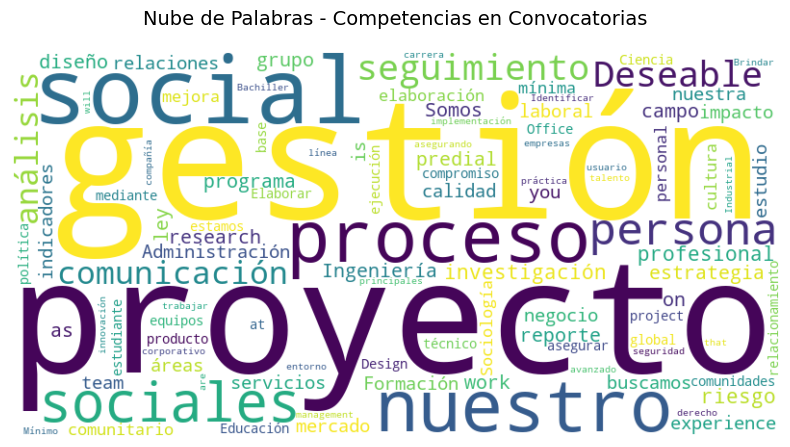

In [11]:
texto_total = " ".join(df['description'].astype(str).tolist())

# 1. Definimos una lista robusta de stopwords en español (artículos, preposiciones, conectores)
stopwords_espanol = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", 
    "un", "para", "con", "no", "una", "su", "al", "lo", "como", "más", "pero", 
    "sus", "le", "ya", "o", "este", "sí", "porque", "esta", "entre", "cuando", 
    "muy", "sin", "sobre", "también", "me", "hasta", "hay", "donde", "quien", 
    "desde", "todo", "nos", "durante", "todos", "uno", "les", "ni", "contra", 
    "otros", "ese", "eso", "ante", "ellos", "e", "esto", "mí", "antes", "algunos", 
    "qué", "unos", "yo", "otro", "otras", "otra", "él", "tanto", "esa", "estos", 
    "mucho", "quienes", "nada", "al", "su", "te", "si", "m", "ser", 
}

# 2. Agregamos las palabras adicionales (incluyendo el "ruido" que vimos en image_9fbb78.png)
palabras_adicionales = {
    # Palabras genéricas de empresa
    "empresa", "puesto", "años", "experiencia", "requisitos", "funciones", 
    "ofrecemos", "necesitamos", "hacer", "trabajo", "equipo", "perú", "beneficios",
    
    # Palabras muy comunes en convocatorias 
    "conocimiento", "conocimientos", "desarrollo", "manejo", "carreras", "afines", 
    "lugar", "sueldo", "disponibilidad", "cumplimiento", "presencial", "mes", 
    "actividades", "nivel", "intermedio", "búsqueda", "participar", "acuerdo", 
    "parte", "toda", "apoyar", "coordinar", "cumplir", "gestionar", "desarrollar", 
    "realizar", "remoto", "modalidad", "cliente", "clientes", "servicio", "área", 
    "información", "datos", "sistema", "sistemas", "herramientas", "manera",
    "capacidad", "objetivo", "organización", "postulación", "oportunidades",
    
    # NUEVO: Conectores en inglés, pronombres sueltos y el símbolo de Soles
    "and", "s", "the", "in", "of", "to", "tu", "es", "día", "u", "our", "or", "i", "for", "we", "with"
}

# Unimos ambas listas
stopwords_espanol.update(palabras_adicionales)

# 3. Generamos la nube (agregamos collocations=False para evitar frases compuestas)
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    stopwords=stopwords_espanol,
    max_words=100,
    colormap='viridis',
    collocations=False 
).generate(texto_total)

# 4. Graficamos
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de Palabras - Competencias en Convocatorias", fontsize=14, pad=20)
plt.show()


In [12]:
habilidades_interes = [
    'excel', 'power bi', 'spss', 'stata', 'rstudio', 'python', 'qgis', 'arcgis', 
    'gestión social', 'relaciones comunitarias', 'proyectos', 'cuantitativa', 'cualitativa'
]

conteo_habilidades = {}
for hab in habilidades_interes:
    coincidencias = df['description'].str.lower().str.contains(hab, na=False).sum()
    conteo_habilidades[hab] = coincidencias

print("--- MENCIÓN DE HERRAMIENTAS Y COMPETENCIAS CLAVE ---")
df_hab = pd.DataFrame(list(conteo_habilidades.items()), columns=['Habilidad / Competencia', 'Ofertas que la mencionan']).sort_values(by='Ofertas que la mencionan', ascending=False)
print(df_hab.to_string(index=False))

--- MENCIÓN DE HERRAMIENTAS Y COMPETENCIAS CLAVE ---
Habilidad / Competencia  Ofertas que la mencionan
                  excel                        77
              proyectos                        77
         gestión social                        31
               power bi                        16
relaciones comunitarias                        12
           cuantitativa                        11
            cualitativa                        11
                 python                         8
                   qgis                         6
                  stata                         5
                 arcgis                         4
                   spss                         3
                rstudio                         2


In [13]:
def estandarizar_ciudad(ubicacion):
    if pd.isna(ubicacion):
        return "No especificado"
    
    # Convertimos a minúsculas y limpiamos espacios
    texto = str(ubicacion).lower().strip()
    
    # Lista ampliada de distritos o términos de Lima Metropolitana
    distritos_lima = [
        'lima', 'lim', 'los olivos', 'miraflores', 'san isidro', 'surco', 
        'la molina', 'san borja', 'jesus maria', 'magdalena', 'pueblo libre', 
        'san miguel', 'ate', 'villa maría', 'villa maria', 'triunfo', 'la victoria', 'chorrillos'
    ]
    
    # 1. Agrupamos Lima y sus distritos
    if any(distrito in texto for distrito in distritos_lima):
        return 'Lima'
        
    # 2. Callao
    elif 'callao' in texto or 'cal' in texto.replace(',', ' ').split():
        return 'Callao'
        
    # 3. Arequipa
    elif 'arequipa' in texto or 'are' in texto.replace(',', ' ').split():
        return 'Arequipa'
        
    # 4. Moquegua e Ilo
    elif 'moquegua' in texto or 'moq' in texto.replace(',', ' ').split():
        return 'Moquegua'
    elif 'ilo' in texto:
        return 'Ilo'
        
    # 5. Trujillo
    elif 'trujillo' in texto or 'lli' in texto.replace(',', ' ').split():
        return 'Trujillo'
        
    # 6. Huancayo
    elif 'huancayo' in texto or 'jun' in texto.replace(',', ' ').split():
        return 'Huancayo'
        
    # 7. Remoto
    elif 'remote' in texto or 'remoto' in texto:
        return 'Remoto'
        
    # Si es otra ciudad, limpiamos el texto tomando la primera parte antes de la coma
    return str(ubicacion).split(',')[0].strip().title()

# Aplicamos la función directamente sobre df
df['Ciudad'] = df['location'].apply(estandarizar_ciudad)

# Verificamos los resultados limpios
print("--- TOP CIUDADES LIMPIAS Y AGRUPADAS ---")
print(df['Ciudad'].value_counts().head(10))

--- TOP CIUDADES LIMPIAS Y AGRUPADAS ---
Ciudad
Lima                    113
No especificado          12
Moquegua                  9
Arequipa                  6
Trujillo                  4
Remoto                    4
Callao                    2
Province Of Asunción      2
Chiclayo                  2
Cusco                     2
Name: count, dtype: int64
